# 03. TRỰC QUAN HÓA DỮ LIỆU USD/VND

Notebook thực hiện thống kê mô tả và trực quan hóa trên **tập Train** để tránh nhìn trước Validation/Test. Các biến phân tích giữ nguyên như bộ gốc: `Close`, `log_price`, `log_return`, rolling volatility và squared return.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from pathlib import Path

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "code":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "figures"
RESULT_DIR = BASE_DIR / "results"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)



In [3]:
# ============================================================
# 1. ĐỌC TRAIN DATA
# ============================================================

price_train = pd.read_csv(
    DATA_DIR / "price_train.csv",
    parse_dates=["Date"]
)

return_train = pd.read_csv(
    DATA_DIR / "return_train.csv",
    parse_dates=["Date"]
)

print("Đọc dữ liệu thành công!")

print("\nPrice train:")
print(price_train.shape)

print("\nReturn train:")
print(return_train.shape)

print("\nThời gian:")
print(
    price_train["Date"].min(),
    "->",
    price_train["Date"].max()
)

Đọc dữ liệu thành công!

Price train:
(2347, 6)

Return train:
(2346, 7)

Thời gian:
2016-01-04 00:00:00 -> 2024-12-31 00:00:00


In [4]:
# ============================================================
# 2. THỐNG KÊ MÔ TẢ GIÁ
# ============================================================

print("\n" + "=" * 65)
print("THỐNG KÊ MÔ TẢ TỶ GIÁ USD/VND")
print("=" * 65)

print(price_train["Close"].describe())


THỐNG KÊ MÔ TẢ TỶ GIÁ USD/VND
count     2347.000000
mean     23304.647422
std        794.205698
min      22171.000000
25%      22755.000000
50%      23178.000000
75%      23453.000000
max      25480.000000
Name: Close, dtype: float64


In [5]:
# ============================================================
# 3. THỐNG KÊ MÔ TẢ LOG-RETURN
# ============================================================

r = return_train["log_return"].dropna()

print("\n" + "=" * 65)
print("THỐNG KÊ LOG-RETURN")
print("=" * 65)

print(r.describe())

print("\nMean:")
print(r.mean())

print("\nStandard deviation:")
print(r.std())

print("\nSkewness:")
print(skew(r, bias=False))

print("\nExcess Kurtosis:")
print(
    kurtosis(
        r,
        fisher=True,
        bias=False
    )
)



THỐNG KÊ LOG-RETURN
count    2346.000000
mean        0.005446
std         0.134041
min        -1.531170
25%        -0.034180
50%         0.000000
75%         0.040278
max         1.175292
Name: log_return, dtype: float64

Mean:
0.005445951272015315

Standard deviation:
0.13404066386885735

Skewness:
0.030879431890258532

Excess Kurtosis:
17.4752069765966


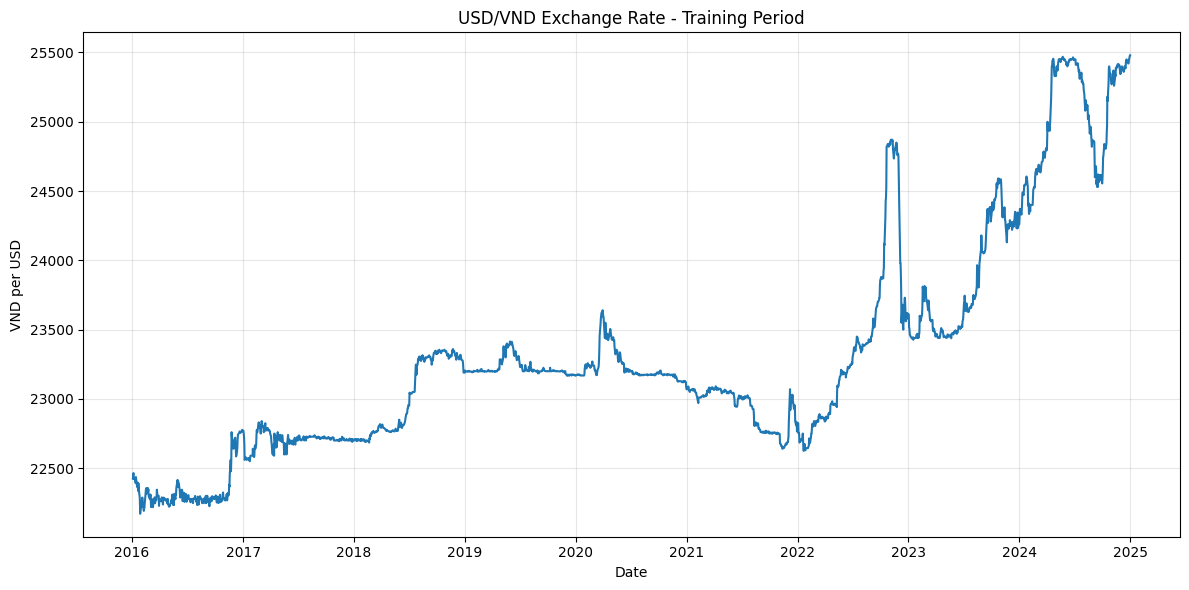

In [6]:
# ============================================================
# 4. ĐỒ THỊ TỶ GIÁ USD/VND
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    price_train["Date"],
    price_train["Close"]
)

plt.title(
    "USD/VND Exchange Rate - Training Period"
)

plt.xlabel("Date")
plt.ylabel("VND per USD")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "01_usd_vnd_rate.png",
    dpi=300
)

plt.show()



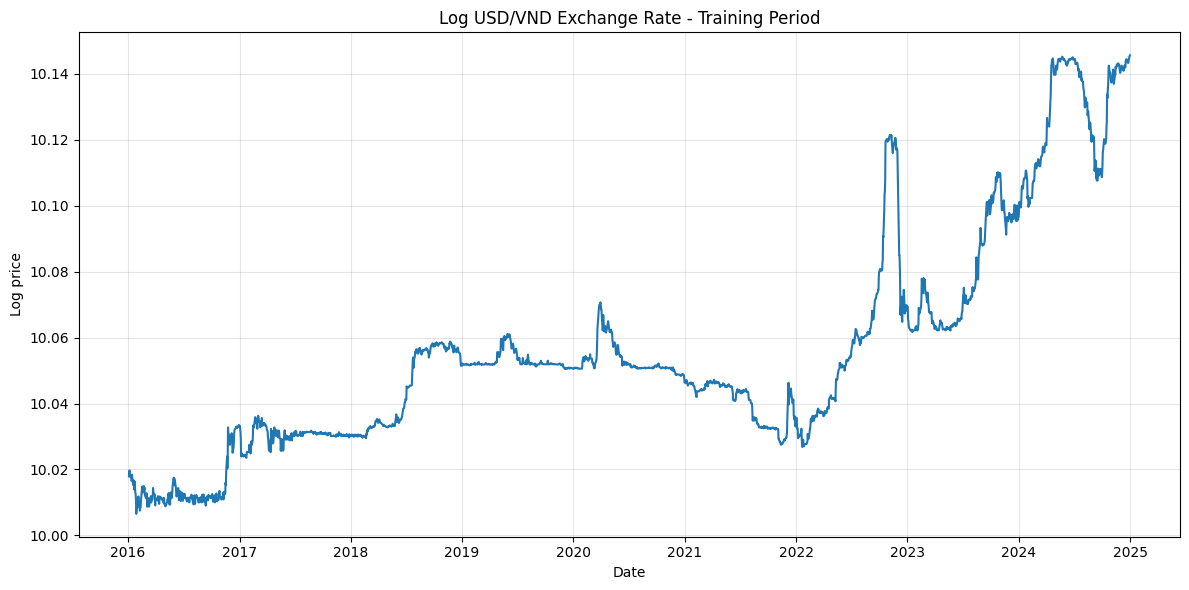

In [7]:
# ============================================================
# 5. ĐỒ THỊ LOG-PRICE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    price_train["Date"],
    price_train["log_price"]
)

plt.title(
    "Log USD/VND Exchange Rate - Training Period"
)

plt.xlabel("Date")
plt.ylabel("Log price")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "02_log_price.png",
    dpi=300
)

plt.show()


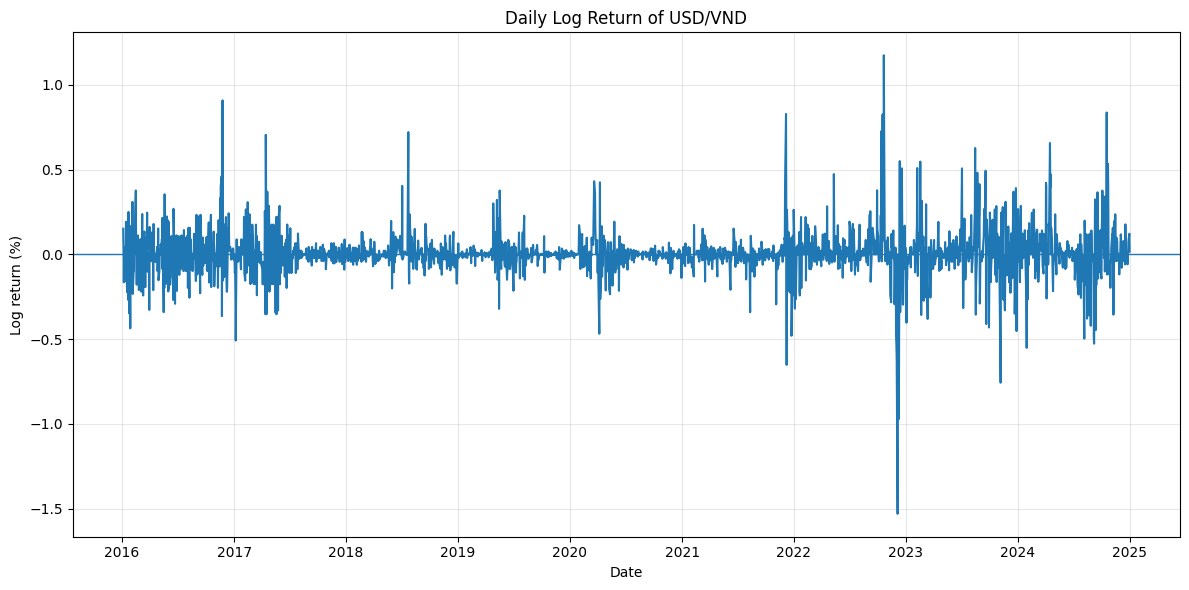

In [8]:
# ============================================================
# 6. ĐỒ THỊ LOG-RETURN
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    return_train["Date"],
    return_train["log_return"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Daily Log Return of USD/VND"
)

plt.xlabel("Date")
plt.ylabel("Log return (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "03_log_return.png",
    dpi=300
)

plt.show()


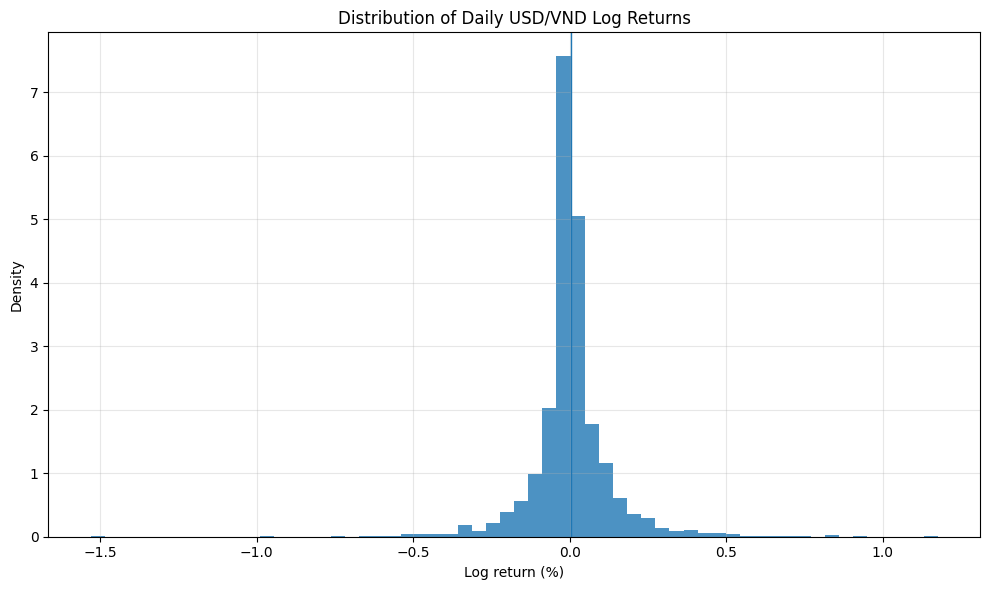

In [9]:
# ============================================================
# 7. HISTOGRAM LOG-RETURN
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    r,
    bins=60,
    density=True,
    alpha=0.8
)

plt.axvline(
    r.mean(),
    linewidth=1
)

plt.title(
    "Distribution of Daily USD/VND Log Returns"
)

plt.xlabel("Log return (%)")
plt.ylabel("Density")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "04_return_histogram.png",
    dpi=300
)

plt.show()


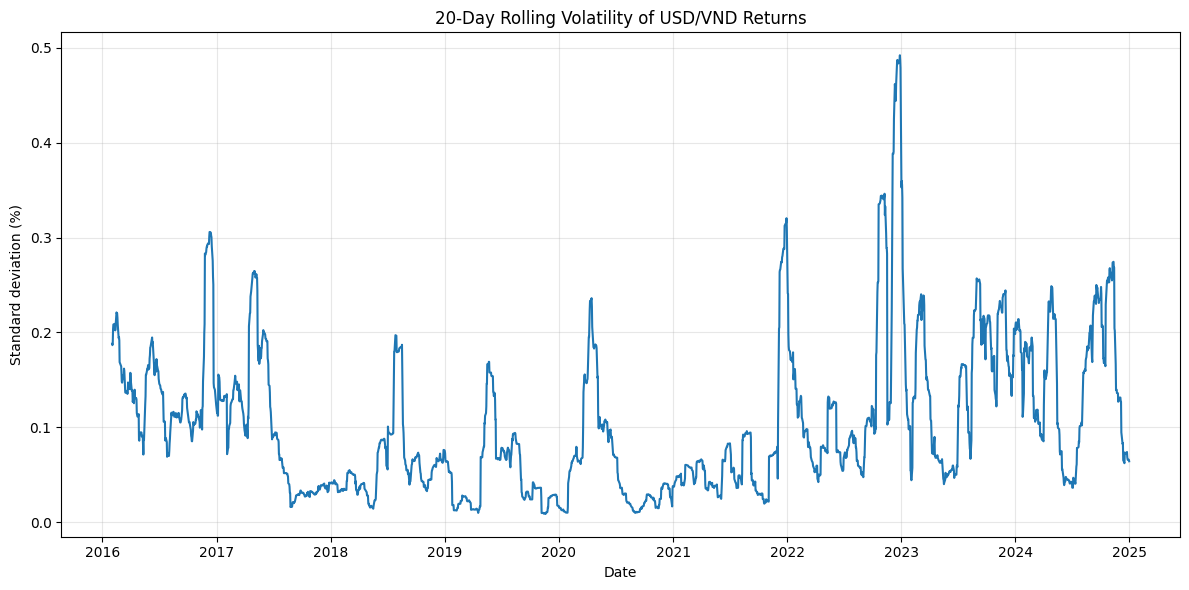

In [10]:
# ============================================================
# 8. ROLLING VOLATILITY
# ============================================================

return_train["rolling_vol_20"] = (
    return_train["log_return"]
    .rolling(window=20)
    .std()
)

plt.figure(figsize=(12, 6))

plt.plot(
    return_train["Date"],
    return_train["rolling_vol_20"]
)

plt.title(
    "20-Day Rolling Volatility of USD/VND Returns"
)

plt.xlabel("Date")
plt.ylabel("Standard deviation (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "05_rolling_volatility.png",
    dpi=300
)

plt.show()


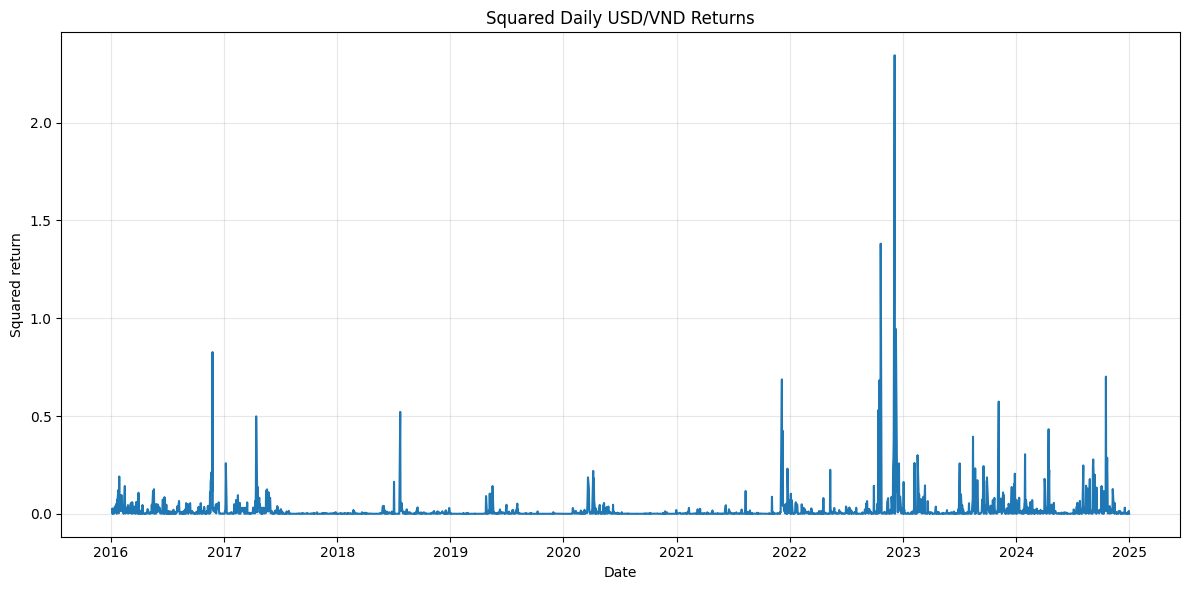

In [11]:
# ============================================================
# 9. SQUARED RETURN
# ============================================================

if "squared_return" not in return_train.columns:
    return_train["squared_return"] = (
        return_train["log_return"] ** 2
    )

plt.figure(figsize=(12, 6))

plt.plot(
    return_train["Date"],
    return_train["squared_return"]
)

plt.title(
    "Squared Daily USD/VND Returns"
)

plt.xlabel("Date")
plt.ylabel("Squared return")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "06_squared_return.png",
    dpi=300
)

plt.show()



In [12]:
# ============================================================
# 10. TÌM NHỮNG NGÀY BIẾN ĐỘNG LỚN
# ============================================================

largest_moves = (
    return_train[
        ["Date", "Close", "log_return"]
    ]
    .assign(
        abs_return=lambda x:
        x["log_return"].abs()
    )
    .sort_values(
        "abs_return",
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 65)
print("20 PHIÊN CÓ |LOG-RETURN| LỚN NHẤT")
print("=" * 65)

print(
    largest_moves[
        ["Date", "Close", "log_return"]
    ].to_string(index=False)
)




20 PHIÊN CÓ |LOG-RETURN| LỚN NHẤT
      Date   Close  log_return
2022-12-05 23980.0   -1.531170
2022-10-21 24820.0    1.175292
2022-12-09 23550.0   -0.971907
2016-11-24 22760.0    0.909218
2024-10-17 25180.0    0.837492
2021-12-06 23020.0    0.828794
2022-10-17 24310.0    0.826110
2023-11-06 24335.0   -0.757347
2022-10-13 24120.0    0.728184
2018-07-23 23220.0    0.721806
2017-04-14 22750.0    0.705781
2024-04-15 25180.0    0.657438
2021-12-08 22920.0   -0.652318
2023-08-15 23965.0    0.627880
2022-12-02 24350.0   -0.614127
2024-01-30 24395.0   -0.551867
2022-12-12 23680.0    0.550499
2023-02-17 23810.0    0.547485
2024-10-21 25285.0    0.535344
2022-12-01 24500.0   -0.529209


In [13]:
# ============================================================
# 11. LƯU THỐNG KÊ
# ============================================================

summary = pd.DataFrame({
    "Statistic": [
        "Observations",
        "Mean return",
        "Std return",
        "Minimum return",
        "Maximum return",
        "Skewness",
        "Excess kurtosis"
    ],

    "Value": [
        len(r),
        r.mean(),
        r.std(),
        r.min(),
        r.max(),
        skew(r, bias=False),
        kurtosis(
            r,
            fisher=True,
            bias=False
        )
    ]
})

summary.to_csv(
    RESULT_DIR / "eda_summary.csv",
    index=False
)

print("\nĐã lưu:")
print("figures/01_usd_vnd_rate.png")
print("figures/02_log_price.png")
print("figures/03_log_return.png")
print("figures/04_return_histogram.png")
print("figures/05_rolling_volatility.png")
print("figures/06_squared_return.png")
print("results/eda_summary.csv")


Đã lưu:
figures/01_usd_vnd_rate.png
figures/02_log_price.png
figures/03_log_return.png
figures/04_return_histogram.png
figures/05_rolling_volatility.png
figures/06_squared_return.png
results/eda_summary.csv
